In [55]:
import datetime as dt
import pandas as pd

In [56]:
# Time period of analysis
dateIni = dt.datetime(2023, 1, 1)
dateEnd = dt.datetime(2024, 5, 31)
country = "PT" # Portugal - alternatively "ES" for Spain

### Load Day-ahead market prices

In [57]:
from OMIEData.Downloaders.marginal_price_downloader import MarginalPriceDownloader
from OMIEData.Enums.all_enums import DataTypeInMarginalPriceFile
from OMIEData.FileReaders.marginal_price_file_reader import MarginalPriceFileReader
from OMIEData.DataImport.omie_data_importer_from_folder import OMIEDataImporterFromFolder
workingFolder = 'OMIE_DA'

In [ ]:
# ! Should only be run once to download the data
# This can take time, it is downloading the files from the website..
error = MarginalPriceDownloader().download_data(date_ini=dateIni, date_end=dateEnd, output_folder=workingFolder)

In [58]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
dataTypes = [DataTypeInMarginalPriceFile.PRICE_SPAIN if country=="ES" else DataTypeInMarginalPriceFile.PRICE_PORTUGAL]
fileReader = MarginalPriceFileReader(types=dataTypes)
df_DA = OMIEDataImporterFromFolder(absolute_path=workingFolder,
                                file_reader=fileReader).read_to_dataframe(verbose=False)
df_DA.sort_values(by='DATE', axis=0, inplace=True)

File OMIE_DA\OMIE_Dayahead_Market_Prices.csv does not have the expected format.


In [59]:
df_DA.to_csv(f'{workingFolder}/OMIE_Dayahead_Market_Prices.csv')

In [60]:
DA = df_DA.drop(columns=['DATE', 'CONCEPT']).to_numpy().flatten()

In [61]:
DA

array([0.  , 0.  , 0.  , ..., 5.5 , 3.25,  nan])

### Load Intraday Prices

In [62]:
from OMIEData.Downloaders.intra_day_price_downloader import IntraDayPriceDownloader
workingFolder = 'OMIE_ID'

In [ ]:
# ! Should only be run once to download the data
# This can take time, it is downloading the files from the website..
obj = IntraDayPriceDownloader(1) # We load data from the first session.
obj.download_data(date_ini=dateIni, date_end=dateEnd, output_folder=workingFolder, verbose=False)

In [63]:
line_ix = 3 if country=="ES" else 4

dates = df_DA['DATE'].to_list()
columns = ['DATE', 'CONCEPT'] + [f'H{h}' for h in range(1,26)]
df_ID = pd.DataFrame(columns=columns)
df_ID['DATE'] = dates
df_ID['CONCEPT'] = 'PriceIntra_1'
for index, date in enumerate(dates):
    file_path = f'{workingFolder}/PrecioIntra_1_{date.strftime("%Y%m%d")}.txt'
    with open(file_path, 'r') as file:
        lines = file.readlines()
    price_value = None
    if len(lines) > 4:
        l = lines[line_ix].split(";")
        for hour in range(1, 26):
            price_value = None
            if len(l) > hour+4:
                p = l[hour+4].replace(",",".")
                if "." in p:
                    if len(p) > 0:
                        price_value = float(p)
            df_ID.at[index, f"H{hour}"] = price_value

In [64]:
df_ID.to_csv(f'{workingFolder}/OMIE_Intraday_Market_Prices.csv')

In [65]:
ID = df_ID.drop(columns=['DATE', 'CONCEPT']).to_numpy().flatten().astype(float)

In [66]:
ID

array([ 0.  ,  0.  ,  0.  , ...,  2.24, -0.75,   nan])

### Analysis

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

In [68]:
sns.set_theme("notebook", font_scale=1.5, style="darkgrid")
plt.rcParams['font.size'] = 16
# set legend fontsize to 14
plt.rcParams['legend.fontsize'] = 18
# set the font weight of the legend to bold
plt.rcParams['legend.title_fontsize'] = 18
# set the font size of the x and y labels to 14
plt.rcParams['axes.labelsize'] = 18
# set the font weight of the x and y labels to bold
plt.rcParams['axes.labelweight'] = 'bold'
# set the font size of the x and y ticks to 12
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
# set the font size of the title to 16
plt.rcParams['axes.titlesize'] = 18
# set the font weight of the title to bold
plt.rcParams['axes.titleweight'] = 'bold'

In [69]:
index = []
for date in df_DA['DATE'].values:
    for hour in range(1,26):
        if df_DA.loc[df_DA['DATE'] == date, f'H{hour}'].values[0] is not None:
            index.append((date))

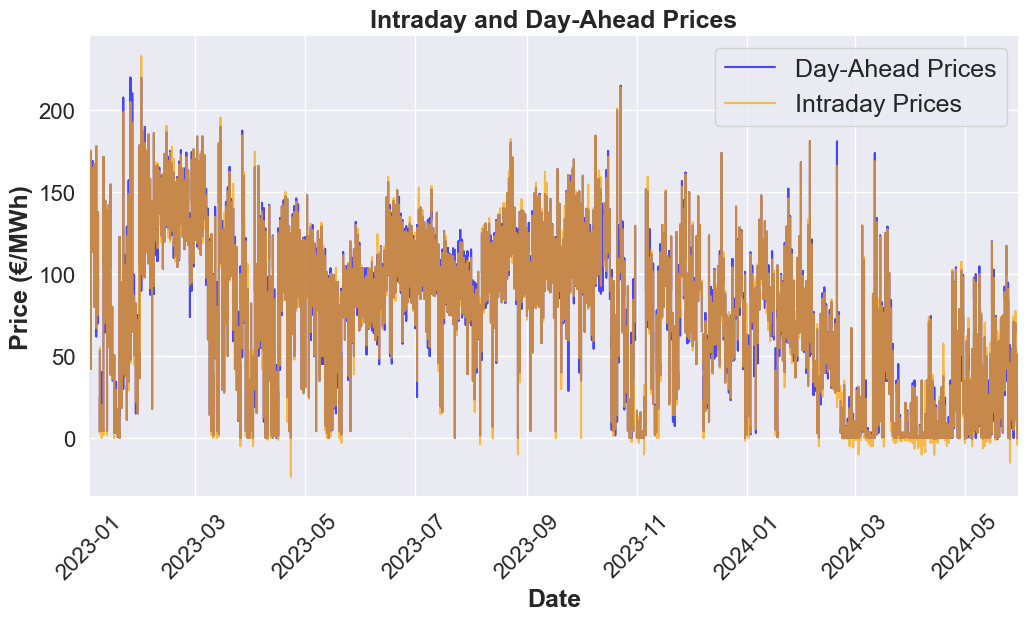

In [70]:
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(index, DA, label='Day-Ahead Prices', color='blue', alpha=0.7)
ax.plot(index, ID, label='Intraday Prices', color='orange', alpha=0.7)
ax.set_title('Intraday and Day-Ahead Prices')
ax.set_xlabel('Date')
ax.set_ylabel('Price (€/MWh)')
plt.xticks(rotation=45)
plt.xlim(dateIni, dateEnd)
ax.legend()
plt.show()

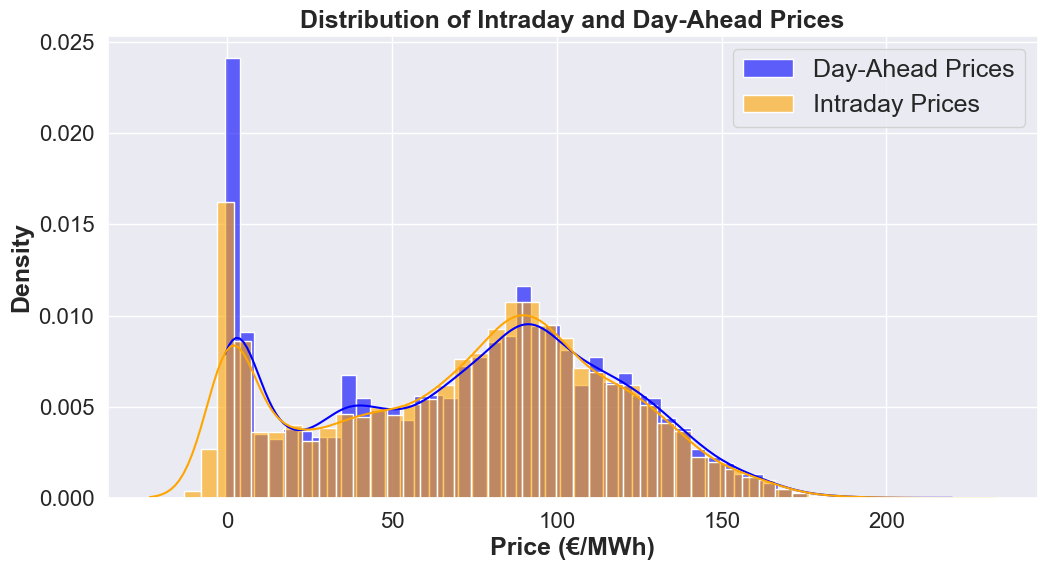

In [71]:
fig, ax = plt.subplots(figsize=(12,6))
sns.histplot(DA, color='blue', label='Day-Ahead Prices', kde=True, stat="density", bins=50, alpha=0.6)
sns.histplot(ID, color='orange', label='Intraday Prices', kde=True, stat="density", bins=50, alpha=0.6)
ax.set_title('Distribution of Intraday and Day-Ahead Prices')
ax.set_xlabel('Price (€/MWh)')
ax.set_ylabel('Density')
ax.legend()
plt.show()

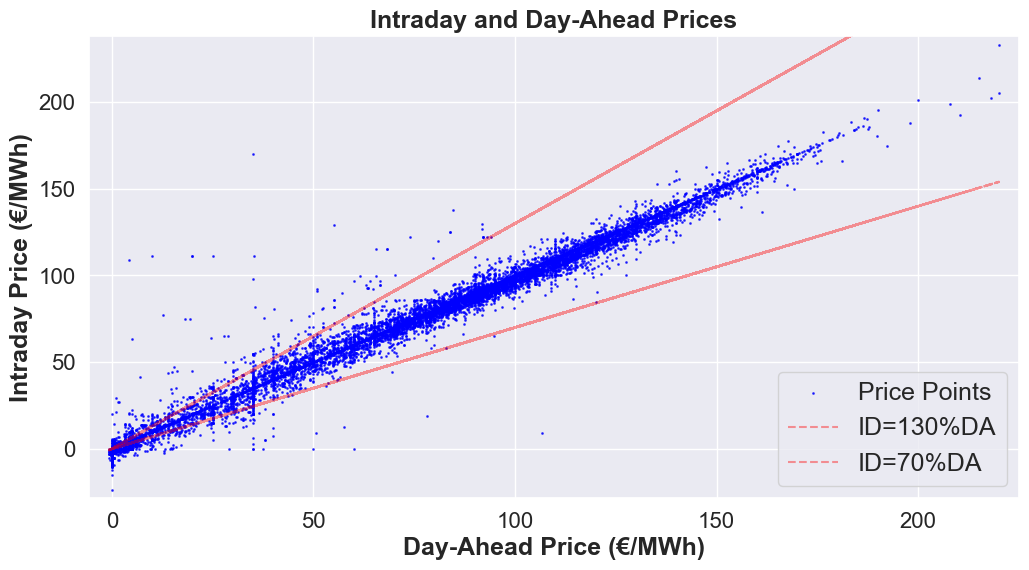

In [72]:
fig, ax = plt.subplots(figsize=(12,6))
ax.set_ylim(min(ID)-5, max(ID)+5)
ax.set_xlim(min(DA)-5, max(DA)+5)
ax.scatter(DA, ID, color='blue', alpha=0.7, s=1, label='Price Points')
# ax.plot(DA, DA, color="red", linestyle="--", label="y=x", alpha=0.4)
ax.plot(DA, 1.30*DA, color="red", linestyle="--", label="ID=130%DA", alpha=0.4)
ax.plot(DA, 0.70*DA, color="red", linestyle="--", label="ID=70%DA", alpha=0.4)
ax.set_title('Intraday and Day-Ahead Prices')
ax.set_xlabel('Day-Ahead Price (€/MWh)')
ax.set_ylabel('Intraday Price (€/MWh)')
ax.legend()
plt.show()

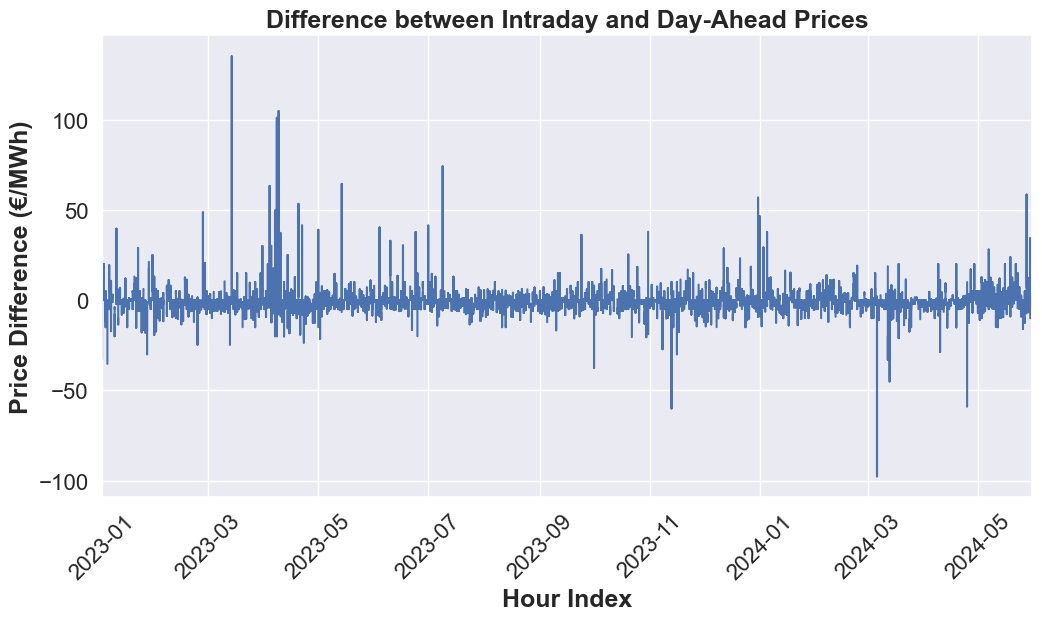

In [73]:
diff = ID - DA
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(index, diff)
ax.set_title('Difference between Intraday and Day-Ahead Prices')
ax.set_xlabel('Hour Index')
ax.set_ylabel('Price Difference (€/MWh)')
plt.xlim(dateIni, dateEnd)
plt.xticks(rotation=45)
plt.show()

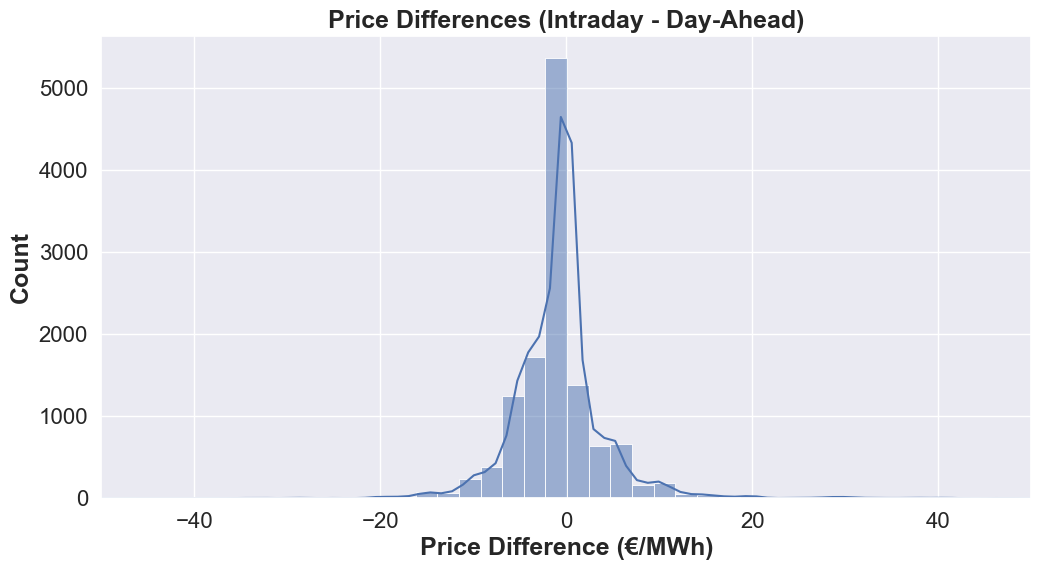

In [74]:
fig, ax = plt.subplots(figsize=(12,6))
sns.histplot(diff, bins=100, kde=True)
plt.title('Price Differences (Intraday - Day-Ahead)')
plt.xlim(-50,50)
plt.xlabel('Price Difference (€/MWh)')
plt.show()

C:\Users\FrederikSkouFertin\AppData\Local\Temp\ipykernel_21552\495423738.py:1: RuntimeWarning: divide by zero encountered in divide
  diff_percent = (ID - DA) / (DA) * 100
C:\Users\FrederikSkouFertin\AppData\Local\Temp\ipykernel_21552\495423738.py:1: RuntimeWarning: invalid value encountered in divide
  diff_percent = (ID - DA) / (DA) * 100


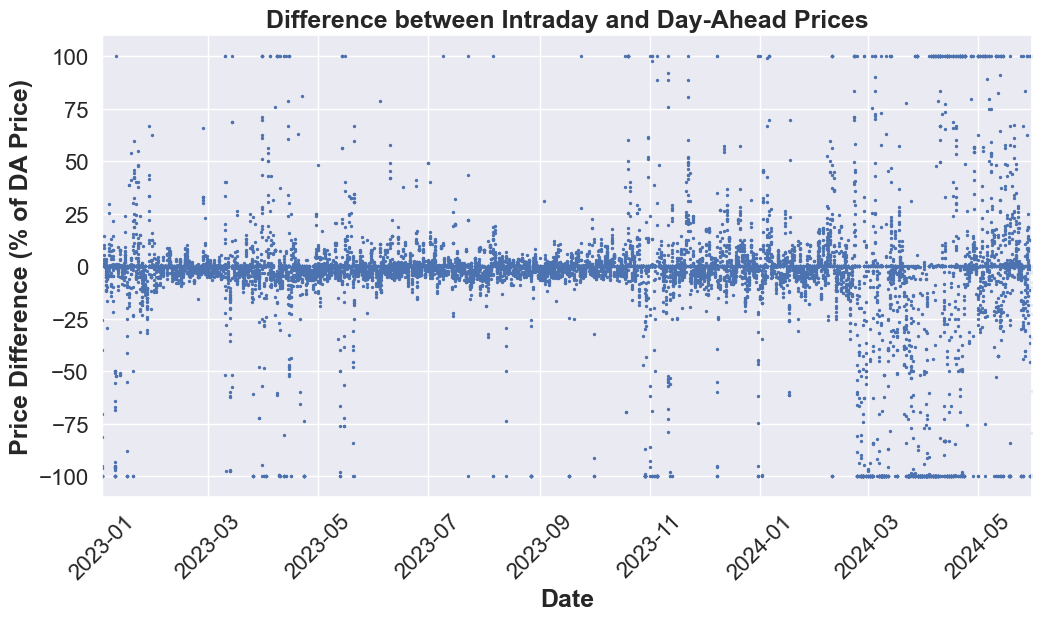

In [75]:
diff_percent = (ID - DA) / (DA) * 100
diff_percent[diff_percent > 100] = 100
diff_percent[diff_percent < -100] = -100
fig, ax = plt.subplots(figsize=(12,6))
ax.scatter(index, diff_percent, s=2)
ax.set_title('Difference between Intraday and Day-Ahead Prices')
ax.set_xlabel('Date')
ax.set_ylabel('Price Difference (% of DA Price)')
plt.xlim(dateIni, dateEnd)
plt.xticks(rotation=45)
plt.show()

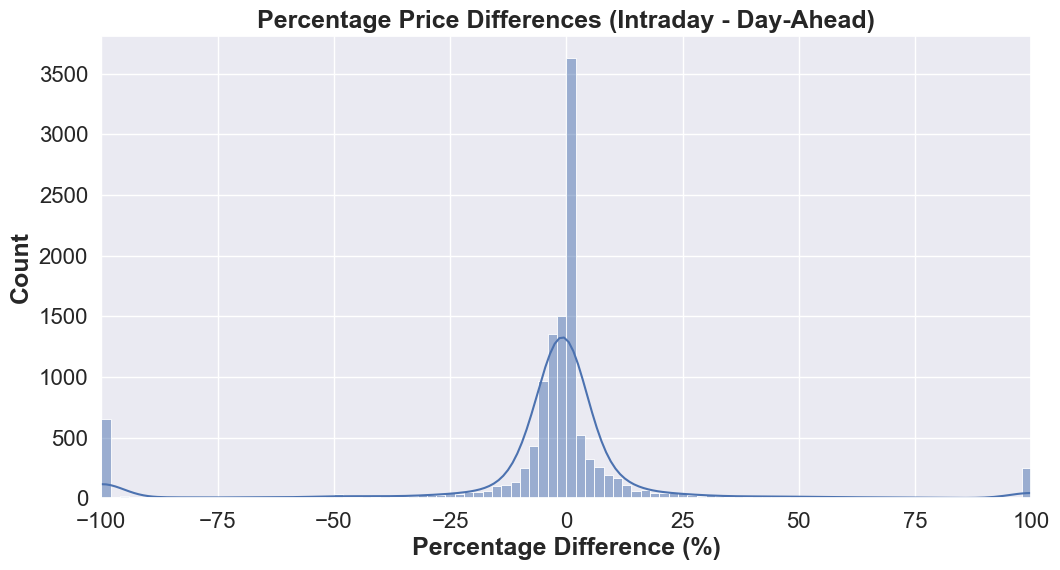

In [76]:
fig, ax = plt.subplots(figsize=(12,6))
sns.histplot(diff_percent, bins=100, kde=True)
plt.title('Percentage Price Differences (Intraday - Day-Ahead)')
plt.xlim(-100,100)
plt.xlabel('Percentage Difference (%)')
plt.show()

In [77]:
print("Percentage of Hours with an ID price 25% lower than the DA: ", round(sum(diff_percent < -25)/len(diff_percent)*100,2), "%")
print("This is bad if we were hoping to make revenue off of selling excess energy in the intraday market compared to the day-ahead market.")

Percentage of Hours with an ID price 25% lower than the DA:  8.57 %
This is bad if we were hoping to make revenue off of selling excess energy in the intraday market compared to the day-ahead market.


In [78]:
print("Percentage of Hours with an ID price 25% higher (or more) than the DA: ", round(sum(diff_percent > 25)/len(diff_percent)*100,2), "%")
print("This is bad if we need to buy energy in the intraday market compared to the day-ahead market.")

Percentage of Hours with an ID price 25% higher (or more) than the DA:  4.67 %
This is bad if we need to buy energy in the intraday market compared to the day-ahead market.


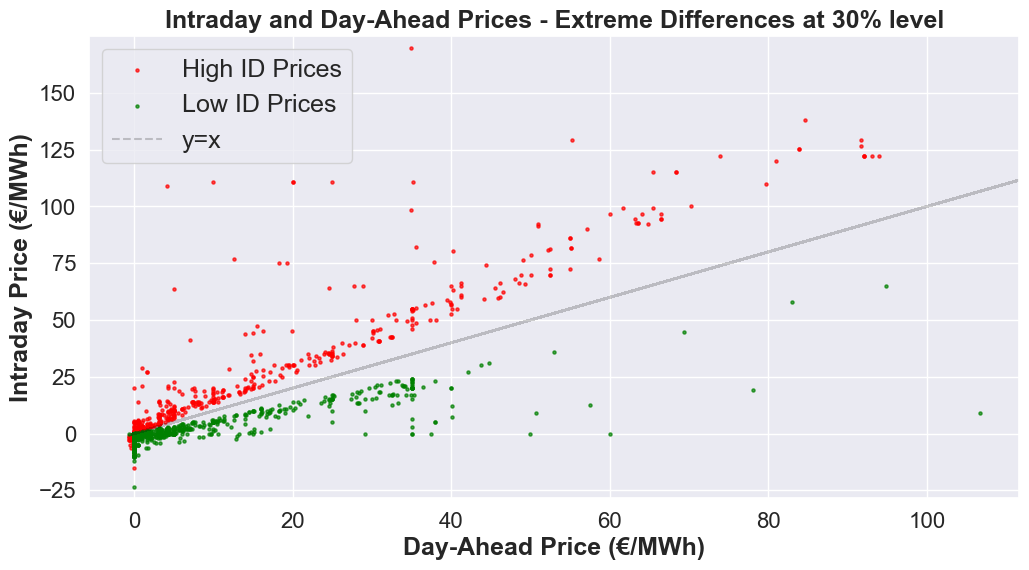

We observe that mostly when we have 'extreme' low intraday prices compared to day-ahead prices, the intraday price is essentially 0 €/MWh, amd the day-ahead price is also fairly low.
We observe that for 'extreme' high intraday prices compared to day-ahead prices, we mostly have low day-ahead prices and low intraday prices, which is a small absolute difference but a large relative difference.
However, there are also cases where the intraday price is very high compared to the day-ahead price, which can be problematic if we need to buy energy in the intraday market those hours.


In [79]:
fig, ax = plt.subplots(figsize=(12,6))
limit=30

ax.set_xlim(min(min(DA[diff_percent <= -limit]),min(DA[diff_percent >= limit]))-5, max(max(DA[diff_percent <= -limit]), max(DA[diff_percent >= limit]))+5)
ax.set_ylim(min(min(ID[diff_percent <= -limit]),min(ID[diff_percent >= limit]))-5, max(max(ID[diff_percent <= -limit]), max(ID[diff_percent >= limit]))+5)

ax.scatter(DA[diff_percent >= limit], ID[diff_percent >= limit], color='red', alpha=0.7, s=5, label='High ID Prices')
ax.scatter(DA[diff_percent <= -limit], ID[diff_percent <= -limit], color='green', alpha=0.7, s=5, label='Low ID Prices')
ax.plot(DA, DA, color="black", linestyle="--", label="y=x", alpha=0.2)
plt.title(f'Intraday and Day-Ahead Prices - Extreme Differences at {limit}% level')
plt.xlabel('Day-Ahead Price (€/MWh)')
plt.ylabel('Intraday Price (€/MWh)')
plt.legend()

plt.show()
print("We observe that mostly when we have 'extreme' low intraday prices compared to day-ahead prices, the intraday price is essentially 0 €/MWh, amd the day-ahead price is also fairly low.")
print("We observe that for 'extreme' high intraday prices compared to day-ahead prices, we mostly have low day-ahead prices and low intraday prices, which is a small absolute difference but a large relative difference.")
print("However, there are also cases where the intraday price is very high compared to the day-ahead price, which can be problematic if we need to buy energy in the intraday market those hours.")